# 05 · Evaluación e interpretación

**Primera y única mirada al conjunto de prueba.** Esas 2.000 filas se apartaron en el notebook 04
y no se han tocado desde entonces: ninguna decisión de modelo, ningún hiperparámetro, ninguna
selección de variables las ha visto.

Por eso las métricas de este notebook estiman de verdad el comportamiento sobre datos nuevos. Si
las hubiéramos consultado antes, estarían midiendo «lo mejor que encontré mirando el test».

### Qué se resuelve aquí

| Sección | Qué |
|---|---|
| B–C | Métricas sobre test, matriz de confusión, curvas ROC y precisión-recall |
| D | **Elección del umbral** por el método pre-registrado en el notebook 00 |
| E | **Calibración** — que el «72% de riesgo» de la app signifique algo |
| F | Interpretabilidad: qué aprendió el modelo y si coincide con el EDA |
| G | **Análisis de sesgo**, separando el coste de `gender` del de `geography` |
| H | Análisis de errores: quién se nos escapa |
| I | Auditoría de **P4** y de los criterios de aceptación |

## A · Carga del modelo y de los datos

El modelo se **carga**, no se reentrena. Así se evalúa exactamente el objeto seleccionado en el
notebook 04. Si MLflow no estuviera disponible, se reconstruye desde los hiperparámetros guardados
en Delta — con `random_state` fijo, el resultado es idéntico.

In [0]:
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                             confusion_matrix, f1_score, precision_recall_curve,
                             precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.width", 175)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

CHURN, SAFE, ACC, GREY = "#a8471f", "#2c5a72", "#8a5a08", "#78736a"

CATALOG      = "bank_churn"
SILVER_TABLE = f"{CATALOG}.silver.bank_customers_clean"

# --- Supuestos económicos: los mismos del notebook 00 ---------------------
MARGEN_ANUAL, HORIZONTE = 200, 3
COSTE_CONTACTO, COSTE_INCENTIVO, TASA_EXITO = 20, 50, 0.30
CAPACIDAD_TOTAL = 800                      # contactos por campaña sobre 10.000 clientes

CLV        = MARGEN_ANUAL * HORIZONTE
VALOR_TP   = TASA_EXITO * CLV - COSTE_CONTACTO - TASA_EXITO * COSTE_INCENTIVO
VALOR_FP   = -(COSTE_CONTACTO + TASA_EXITO * COSTE_INCENTIVO)
UMBRAL_COSTE = -VALOR_FP / (VALOR_TP - VALOR_FP)

print(f"valor de un TP {VALOR_TP:+.0f} EUR · coste de un FP {VALOR_FP:+.0f} EUR")
print(f"umbral de rentabilidad: p = {UMBRAL_COSTE:.3f}")

valor de un TP +145 EUR · coste de un FP -35 EUR
umbral de rentabilidad: p = 0.194


In [0]:
# Reconstruir la misma partición. Es determinista: mismo seed, mismo resultado.
df = spark.table(SILVER_TABLE).toPandas()
df["exited"] = df["exited"].astype(bool)

TARGET   = "exited"
EXCLUIR  = ["customer_id", "_silver_at", "credit_score_band"]
FEATURES = [c for c in df.columns if c not in EXCLUIR + [TARGET]]
BIN      = ["balance_zero", "is_active_member", "has_cr_card"]

X = df[FEATURES].copy()
for c in BIN:
    X[c] = X[c].astype(int)
y = df[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)

# Verificación: debe coincidir con lo que el notebook 04 aparto
guardado = spark.table(f"{CATALOG}.silver.test_holdout").toPandas()
assert len(guardado) == len(X_test), "la partición no coincide con la del notebook 04"
assert abs(guardado["exited"].mean() - y_test.mean()) < 1e-9, "la partición no coincide"
print(f"partición verificada contra silver.test_holdout")
print(f"entrenamiento {len(X_train):,} · prueba {len(X_test):,} (tasa {y_test.mean():.2%})")

ID_TEST = df.loc[X_test.index, "customer_id"].values

particion verificada contra silver.test_holdout
entrenamiento 8,000 · prueba 2,000 (tasa 20.35%)


In [0]:
ref = spark.table(f"{CATALOG}.gold.modelo_seleccionado").toPandas().iloc[0]
print("familia :", ref["familia"])
print("run_id  :", ref["run_id"] or "(no disponible)")

modelo = None
if ref["run_id"]:
    try:
        modelo = mlflow.sklearn.load_model(f"runs:/{ref['run_id']}/modelo")
        print("\nmodelo CARGADO desde MLflow — es exactamente el del notebook 04")
    except Exception as e:
        print(f"\n[aviso] no se pudo cargar de MLflow ({type(e).__name__})")

if modelo is None:
    print("reconstruyendo desde los hiperparámetros guardados en Delta...")
    params = {k: v for k, v in json.loads(ref["params"]).items()}
    CAT_ARBOL = ["geography", "gender"]
    NUM_ARBOL = ["credit_score", "balance", "tenure", "estimated_salary", "age", "num_of_products"]
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_ARBOL),
        ("num", "passthrough", NUM_ARBOL),
        ("bin", "passthrough", BIN)], remainder="drop", verbose_feature_names_out=False)
    clf = RandomForestClassifier(class_weight="balanced_subsample", random_state=SEED,
                                 n_jobs=-1, **params)
    modelo = Pipeline([("prep", prep), ("clf", clf)]).fit(X_train, y_train)
    print("modelo reconstruido (idéntico: random_state fijo)")

print("\n", modelo)

familia : random_forest
run_id  : <run_id>



modelo CARGADO desde MLflow — es exactamente el del notebook 04

 Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['geography', 'gender']),
                                                 ('num', 'passthrough',
                                                  ['credit_score', 'balance',
                                                   'tenure', 'estimated_salary',
                                                   'age', 'num_of_products']),
                                                 ('bin', 'passthrough',
                                                  ['balance_zero',
                                                   'is_active_member',
                                                   'has_cr_card'])],
                  

## B · Métricas sobre el conjunto de prueba

Se reportan a **dos umbrales**: el 0,5 por defecto —solo para documentar por qué no sirve— y el
elegido en la sección D.

In [0]:
proba = modelo.predict_proba(X_test)[:, 1]

def metricas(y_true, p, umbral):
    pred = p >= umbral
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return {
        "umbral": round(umbral, 4),
        "accuracy":  accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall":    recall_score(y_true, pred),
        "f1":        f1_score(y_true, pred),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "contactados": int(pred.sum()),
    }

ROC_AUC = roc_auc_score(y_test, proba)
AP      = average_precision_score(y_test, proba)

print(f"Métricas independientes del umbral:")
print(f"  ROC-AUC           : {ROC_AUC:.4f}")
print(f"  Average precision : {AP:.4f}")
print(f"  Tasa base         : {y_test.mean():.4f}\n")

m05 = metricas(y_test, proba, 0.5)
print("A umbral 0,5 (por defecto, NO es el elegido):")
for k, v in m05.items():
    print(f"  {k:<12} {v:.4f}" if isinstance(v, float) else f"  {k:<12} {v}")

Metricas independientes del umbral:
  ROC-AUC           : 0.8586
  Average precision : 0.6993
  Tasa base         : 0.2035

A umbral 0,5 (por defecto, NO es el elegido):
  umbral       0.5000
  accuracy     0.8340
  precision    0.5776
  recall       0.6855
  f1           0.6270
  TP           279
  FP           204
  FN           128
  TN           1389
  contactados  483


## C · Curvas y matriz de confusión

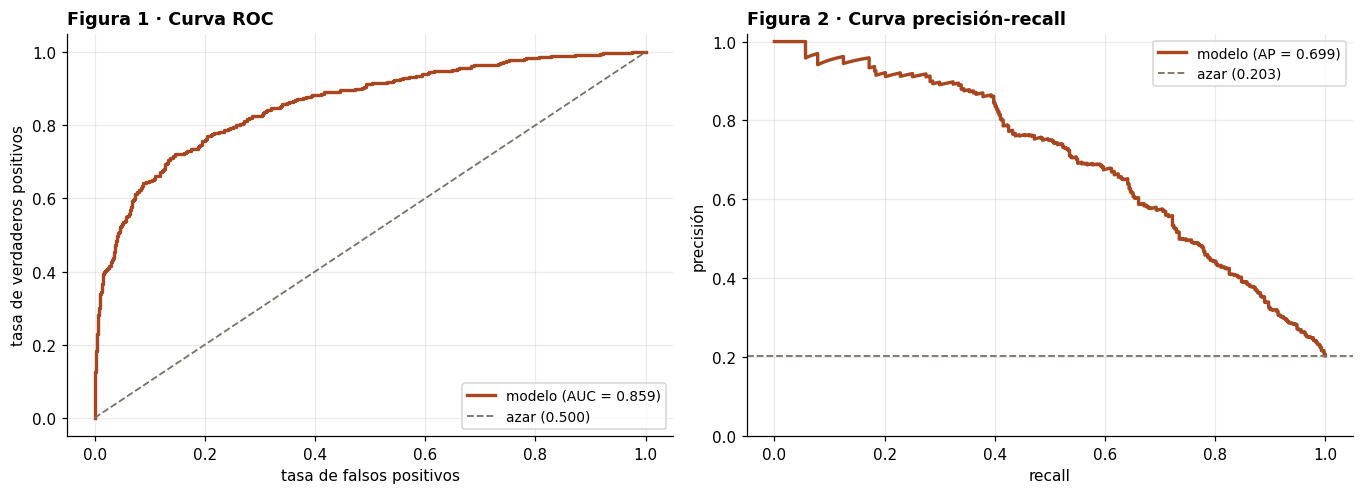

Con clases desbalanceadas, la curva PR es mas informativa: su linea de azar esta en
0.203, no en 0,5. La ROC puede parecer buena aunque la precision sea mala.


In [0]:
fpr, tpr, _   = roc_curve(y_test, proba)
prec, rec, _  = precision_recall_curve(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))

axes[0].plot(fpr, tpr, color=CHURN, lw=2.2, label=f"modelo (AUC = {ROC_AUC:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color=GREY, lw=1.2, label="azar (0.500)")
axes[0].set_xlabel("tasa de falsos positivos"); axes[0].set_ylabel("tasa de verdaderos positivos")
axes[0].set_title("Figura 1 · Curva ROC", fontsize=11.5, fontweight="bold", loc="left")
axes[0].legend(fontsize=9, loc="lower right")

axes[1].plot(rec, prec, color=CHURN, lw=2.2, label=f"modelo (AP = {AP:.3f})")
axes[1].axhline(y_test.mean(), ls="--", color=GREY, lw=1.2,
                label=f"azar ({y_test.mean():.3f})")
axes[1].set_xlabel("recall"); axes[1].set_ylabel("precisión")
axes[1].set_title("Figura 2 · Curva precisión-recall", fontsize=11.5, fontweight="bold", loc="left")
axes[1].legend(fontsize=9, loc="upper right")
axes[1].set_ylim(0, 1.02)

plt.tight_layout(); plt.show()

print("Con clases desbalanceadas, la curva PR es mas informativa: su línea de azar esta en")
print(f"{y_test.mean():.3f}, no en 0,5. La ROC puede parecer buena aunque la precisión sea mala.")

## D · Elección del umbral

Se aplica **el método registrado en el notebook 00**, sin modificarlo:

> `alto` = los `CAPACIDAD` clientes con mayor probabilidad predicha, validado contra el umbral de
> rentabilidad por costes.

La capacidad son 800 contactos sobre 10.000 clientes, es decir el **8% de la base**. Sobre las
2.000 filas de prueba, eso son 160 contactos.

In [0]:
FRACCION_CAPACIDAD = CAPACIDAD_TOTAL / len(df)          # 8% de la base
cupo_test = int(round(FRACCION_CAPACIDAD * len(X_test)))

orden = np.argsort(proba)[::-1]
UMBRAL_CAPACIDAD = float(proba[orden[cupo_test - 1]])

print(f"cupo sobre test        : {cupo_test} contactos ({FRACCION_CAPACIDAD:.1%} de la base)")
print(f"umbral por capacidad   : p >= {UMBRAL_CAPACIDAD:.4f}")
print(f"umbral por rentabilidad: p >= {UMBRAL_COSTE:.4f}")

if UMBRAL_CAPACIDAD >= UMBRAL_COSTE:
    UMBRAL = UMBRAL_CAPACIDAD
    print("\n-> Manda la CAPACIDAD. Todos los contactados superan el umbral de rentabilidad,")
    print("   así que contactarlos genera valor. La restricción es el presupuesto, no el coste.")
else:
    UMBRAL = UMBRAL_COSTE
    print("\n-> Manda el COSTE. El cupo llegaría a clientes por debajo del umbral de")
    print("   rentabilidad: contactarlos destruiría valor, así que se recorta la lista.")

print(f"\nUMBRAL ELEGIDO: {UMBRAL:.4f}")

cupo sobre test        : 160 contactos (8.0% de la base)
umbral por capacidad   : p >= 0.8333
umbral por rentabilidad: p >= 0.1944

-> Manda la CAPACIDAD. Todos los contactados superan el umbral de rentabilidad,
   asi que contactarlos genera valor. La restriccion es el presupuesto, no el coste.

UMBRAL ELEGIDO: 0.8333


In [0]:
m_final = metricas(y_test, proba, UMBRAL)
valor_modelo = m_final["TP"] * VALOR_TP + m_final["FP"] * VALOR_FP

# Línea base de negocio al MISMO volumen de contactos
seg = X_test.assign(_ag=df.loc[X_test.index, "age_group"].values,
                    _act=X_test["is_active_member"].values)
tasas_train = (pd.DataFrame({"ag": df.loc[X_train.index, "age_group"].values,
                             "act": X_train["is_active_member"].values,
                             "y": y_train.values})
                 .groupby(["ag", "act"])["y"].mean())
score_regla = pd.MultiIndex.from_arrays([seg["_ag"], seg["_act"]]).map(tasas_train).to_numpy(float)

orden_regla = np.argsort(score_regla)[::-1][:cupo_test]
tp_regla = int(y_test.iloc[orden_regla].sum())
valor_regla = tp_regla * VALOR_TP + (cupo_test - tp_regla) * VALOR_FP

comp = pd.DataFrame([
    {"estrategia": "Modelo (Random Forest)", "contactos": m_final["contactados"],
     "abandonos_captados": m_final["TP"], "precision": m_final["TP"] / m_final["contactados"],
     "recall": m_final["recall"], "valor_esperado_EUR": valor_modelo},
    {"estrategia": "Regla de negocio", "contactos": cupo_test,
     "abandonos_captados": tp_regla, "precision": tp_regla / cupo_test,
     "recall": tp_regla / int(y_test.sum()), "valor_esperado_EUR": valor_regla},
]).set_index("estrategia")

print("--- CON EL MISMO VOLUMEN DE CONTACTOS ---")
print(comp.round(4).to_string())
print(f"\nventaja del modelo: {m_final['TP'] - tp_regla:+d} abandonos captados "
      f"({valor_modelo - valor_regla:+,.0f} EUR)")
print(f"\nExtrapolado a la base completa ({CAPACIDAD_TOTAL} contactos):")
factor = len(df) / len(X_test)
print(f"  modelo {m_final['TP']*factor:,.0f} abandonos · {valor_modelo*factor:+,.0f} EUR")
print(f"  regla  {tp_regla*factor:,.0f} abandonos · {valor_regla*factor:+,.0f} EUR")

--- CON EL MISMO VOLUMEN DE CONTACTOS ---
                        contactos  abandonos_captados  precision  recall  valor_esperado_EUR
estrategia                                                                                  
Modelo (Random Forest)        160                 140     0.8750  0.3440             19600.0
Regla de negocio              160                 103     0.6438  0.2531             12940.0

ventaja del modelo: +37 abandonos captados (+6,660 EUR)

Extrapolado a la base completa (800 contactos):
  modelo 700 abandonos · +98,000 EUR
  regla  515 abandonos · +64,700 EUR


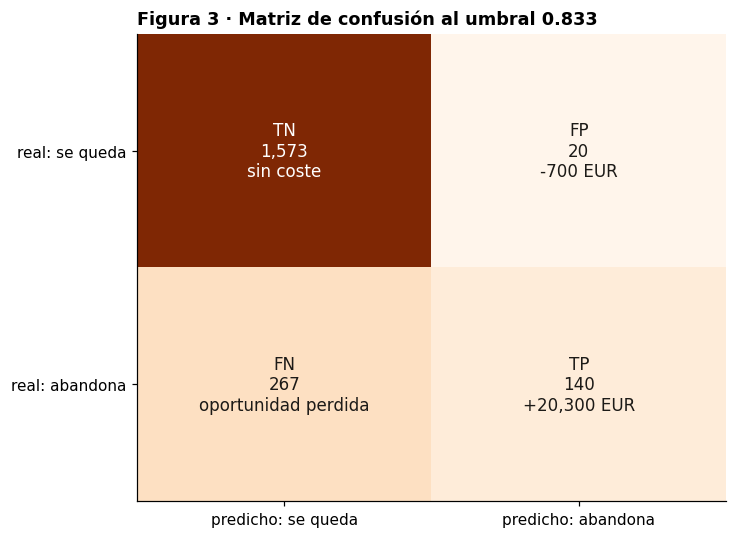

Los 267 falsos negativos son el error caro: clientes que se van sin que
nadie lo intente. Los 20 falsos positivos cuestan 700 EUR en
contactos desperdiciados — molesto, pero recuperable.


In [0]:
# Figura 3 · matriz de confusión al umbral elegido, con lectura en euros
cm = confusion_matrix(y_test, proba >= UMBRAL)
etiquetas = np.array([[f"TN\n{cm[0,0]:,}\nsin coste", f"FP\n{cm[0,1]:,}\n{cm[0,1]*VALOR_FP:+,.0f} EUR"],
                      [f"FN\n{cm[1,0]:,}\noportunidad perdida", f"TP\n{cm[1,1]:,}\n{cm[1,1]*VALOR_TP:+,.0f} EUR"]])

fig, ax = plt.subplots(figsize=(6.8, 5))
im = ax.imshow(cm, cmap="Oranges", aspect="auto")
for i in range(2):
    for j in range(2):
        ax.text(j, i, etiquetas[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.5 else "#1c1a17")
ax.set_xticks([0, 1]); ax.set_xticklabels(["predicho: se queda", "predicho: abandona"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["real: se queda", "real: abandona"])
ax.set_title(f"Figura 3 · Matriz de confusión al umbral {UMBRAL:.3f}",
             fontsize=11.5, fontweight="bold", loc="left")
ax.grid(False)
plt.tight_layout(); plt.show()

print(f"Los {cm[1,0]:,} falsos negativos son el error caro: clientes que se van sin que")
print(f"nadie lo intente. Los {cm[0,1]:,} falsos positivos cuestan {cm[0,1]*abs(VALOR_FP):,.0f} EUR en")
print("contactos desperdiciados — molesto, pero recuperable.")

## E · Calibración

La app va a mostrar un número al equipo de retención. Si dice «72% de riesgo» y de ese grupo solo
se va el 40%, la campaña se dimensiona mal.

**Calibrar no es lo mismo que discriminar.** Un modelo puede ordenar perfectamente a los clientes
—ROC-AUC alto— y aun así dar probabilidades sistemáticamente sesgadas.

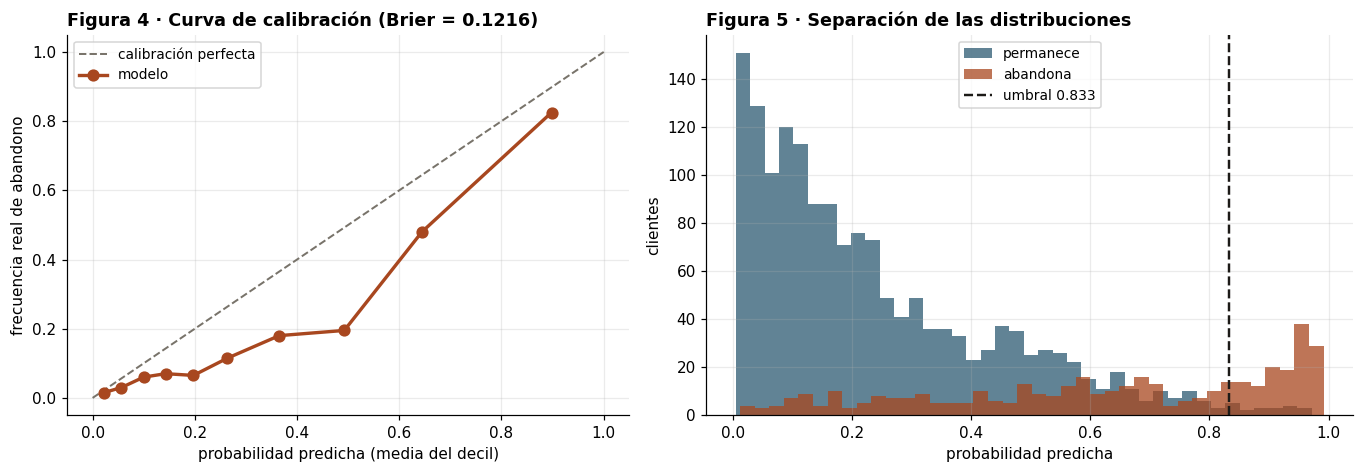

 predicho  real  desvio_pp
    0.021 0.015       -0.6
    0.056 0.030       -2.6
    0.100 0.060       -4.0
    0.143 0.070       -7.3
    0.197 0.065      -13.2
    0.264 0.115      -14.9
    0.365 0.180      -18.5
    0.492 0.195      -29.7
    0.644 0.480      -16.4
    0.898 0.825       -7.3

Brier score: 0.1216 (menor es mejor; 0 seria perfecto)
Desvio maximo: 29.7 puntos porcentuales


In [0]:
frac_real, media_pred = calibration_curve(y_test, proba, n_bins=10, strategy="quantile")
brier = brier_score_loss(y_test, proba)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.15]})

axes[0].plot([0, 1], [0, 1], "--", color=GREY, lw=1.3, label="calibración perfecta")
axes[0].plot(media_pred, frac_real, "o-", color=CHURN, lw=2.2, ms=7, label="modelo")
axes[0].set_xlabel("probabilidad predicha (media del decil)")
axes[0].set_ylabel("frecuencia real de abandono")
axes[0].set_title(f"Figura 4 · Curva de calibración (Brier = {brier:.4f})",
                  fontsize=11.5, fontweight="bold", loc="left")
axes[0].legend(fontsize=9)

axes[1].hist(proba[~y_test.values], bins=40, alpha=0.75, color=SAFE, label="permanece")
axes[1].hist(proba[y_test.values],  bins=40, alpha=0.75, color=CHURN, label="abandona")
axes[1].axvline(UMBRAL, color="#1c1a17", ls="--", lw=1.6, label=f"umbral {UMBRAL:.3f}")
axes[1].set_xlabel("probabilidad predicha"); axes[1].set_ylabel("clientes")
axes[1].set_title("Figura 5 · Separación de las distribuciones",
                  fontsize=11.5, fontweight="bold", loc="left")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

cal = pd.DataFrame({"predicho": media_pred, "real": frac_real})
cal["desvio_pp"] = ((cal["real"] - cal["predicho"]) * 100).round(1)
print(cal.round(3).to_string(index=False))
print(f"\nBrier score: {brier:.4f} (menor es mejor; 0 sería perfecto)")
print(f"Desvio máximo: {cal['desvio_pp'].abs().max():.1f} puntos porcentuales")

## F · Interpretabilidad

Dos preguntas: **qué variables usa** el modelo, y **con qué forma** las usa. La segunda es la que
permite comprobar si aprendió lo que el EDA describió.

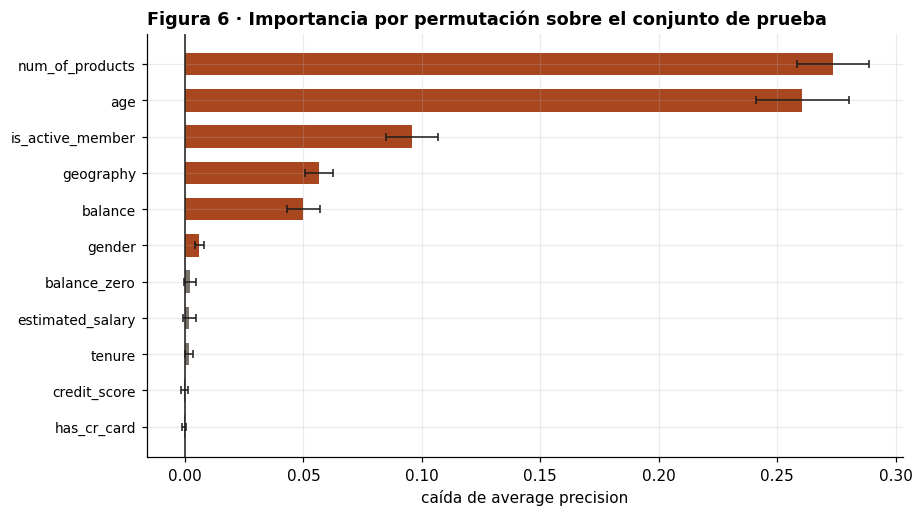

                  importancia     std  distinguible_de_cero
variable                                                   
num_of_products        0.2734  0.0152                  True
age                    0.2606  0.0196                  True
is_active_member       0.0959  0.0110                  True
geography              0.0566  0.0060                  True
balance                0.0499  0.0070                  True
gender                 0.0061  0.0018                  True
balance_zero           0.0022  0.0024                 False
estimated_salary       0.0019  0.0028                 False
tenure                 0.0017  0.0016                 False
credit_score          -0.0002  0.0014                 False
has_cr_card           -0.0003  0.0008                 False

6 de 11 variables tienen efecto distinguible de cero (>2 desviaciones).


In [0]:
prep_fit = modelo.named_steps["prep"]
usadas = sorted({c for _, _, cols in prep_fit.transformers_
                 for c in (cols if isinstance(cols, list) else [])})

perm = permutation_importance(modelo, X_test[usadas], y_test, scoring="average_precision",
                              n_repeats=15, random_state=SEED, n_jobs=-1)
imp = (pd.DataFrame({"variable": usadas, "importancia": perm.importances_mean,
                     "std": perm.importances_std})
         .sort_values("importancia", ascending=False).set_index("variable"))

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ypos = np.arange(len(imp))[::-1]
sig = imp["importancia"] > 2 * imp["std"]          # distinguible de cero
ax.barh(ypos, imp["importancia"], xerr=imp["std"],
        color=[CHURN if s else GREY for s in sig], height=0.62,
        error_kw=dict(ecolor="#1c1a17", lw=1, capsize=2.5))
ax.set_yticks(ypos); ax.set_yticklabels(imp.index, fontsize=9)
ax.axvline(0, color="#1c1a17", lw=1)
ax.set_title("Figura 6 · Importancia por permutación sobre el conjunto de prueba",
             fontsize=11.5, fontweight="bold", loc="left")
ax.set_xlabel("caída de average precision")
plt.tight_layout(); plt.show()

imp["distinguible_de_cero"] = sig
print(imp.round(4).to_string())
print(f"\n{int(sig.sum())} de {len(imp)} variables tienen efecto distinguible de cero (>2 desviaciones).")

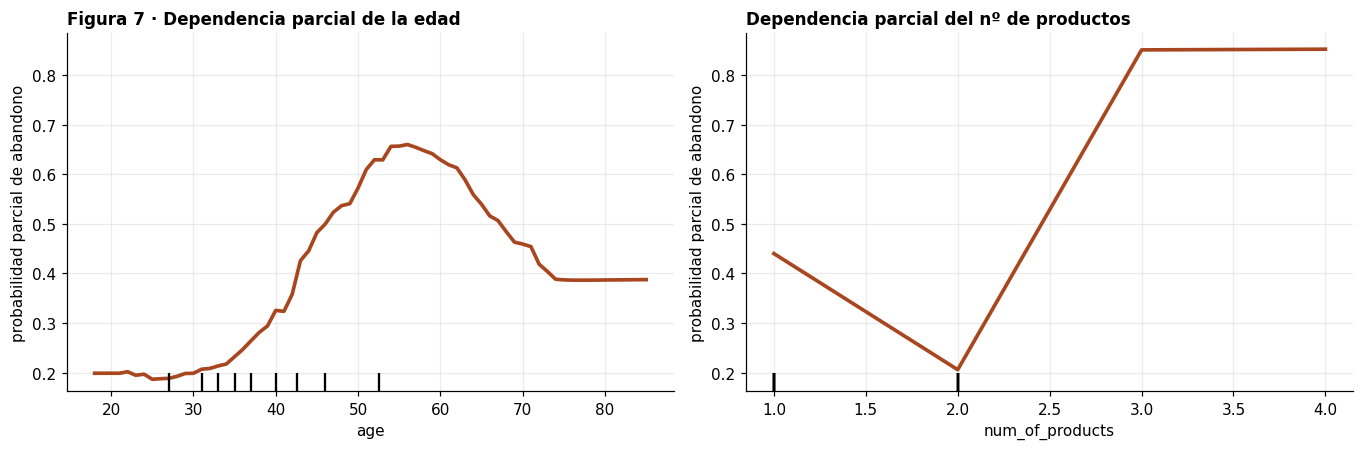

Comprobacion contra el EDA: la curva de edad deberia subir hasta los 50-60 y aplanarse o
caer despues; la de productos deberia bajar de 1 a 2 y dispararse en 3 y 4.
Si el modelo reprodujo esas formas, aprendio la estructura que el analisis describio.


In [0]:
# Figura 7 · dependencia parcial: la FORMA que aprendió el modelo
fig, ax = plt.subplots(1, 2, figsize=(12.5, 4.2))
PartialDependenceDisplay.from_estimator(
    modelo, X_test, features=["age", "num_of_products"],
    ax=ax, line_kw={"color": CHURN, "lw": 2.4})
ax[0].set_title("Figura 7 · Dependencia parcial de la edad", fontsize=11,
                fontweight="bold", loc="left")
ax[1].set_title("Dependencia parcial del nº de productos", fontsize=11,
                fontweight="bold", loc="left")
for a in ax:
    a.set_ylabel("probabilidad parcial de abandono")
plt.tight_layout(); plt.show()

print("Comprobación contra el EDA: la curva de edad debería subir hasta los 50-60 y aplanarse o")
print("caer después; la de productos debería bajar de 1 a 2 y dispararse en 3 y 4.")
print("Si el modelo reprodujo esas formas, aprendió la estructura que el análisis describió.")

## G · Análisis de sesgo

El enunciado exige analizar `gender` y `geography` desde la perspectiva de equidad y justificar su
uso. Se hace en dos niveles: **desempeño por grupo** y **coste real de excluir cada variable**.

El notebook 04 midió el coste de excluir **ambas** (3,37 pp de recall). Aquí se separan, porque la
permutación sugería que `gender` apenas aporta — y si excluirlo sale casi gratis, la recomendación
cambia por completo.

In [0]:
pred = proba >= UMBRAL
grupos = pd.DataFrame({
    "geography": df.loc[X_test.index, "geography"].values,
    "gender":    df.loc[X_test.index, "gender"].values,
    "real":      y_test.values,
    "pred":      pred,
    "proba":     proba,
})

def por_grupo(col):
    filas = []
    for g, sub in grupos.groupby(col):
        tn, fp, fn, tp = confusion_matrix(sub["real"], sub["pred"], labels=[False, True]).ravel()
        filas.append({
            col: g, "n": len(sub),
            "tasa_real": sub["real"].mean(),
            "tasa_marcados": sub["pred"].mean(),
            "recall": tp / (tp + fn) if tp + fn else np.nan,
            "precision": tp / (tp + fp) if tp + fp else np.nan,
            "FPR": fp / (fp + tn) if fp + tn else np.nan,
        })
    return pd.DataFrame(filas).set_index(col)

for col in ["geography", "gender"]:
    t = por_grupo(col)
    brecha = (t["recall"].max() - t["recall"].min()) * 100
    print(f"— {col} —")
    print(t.round(4).to_string())
    print(f"  brecha de recall entre grupos: {brecha:.1f} puntos "
          f"({'DENTRO' if brecha <= 10 else 'FUERA'} del criterio de <= 10 pp)\n")

— geography —
              n  tasa_real  tasa_marcados  recall  precision     FPR
geography                                                           
France     1021     0.1714         0.0470  0.2514     0.9167  0.0047
Germany     504     0.2996         0.1687  0.4636     0.8235  0.0425
Spain       475     0.1705         0.0568  0.3210     0.9630  0.0025
  brecha de recall entre grupos: 21.2 puntos (FUERA del criterio de <= 10 pp)

— gender —
           n  tasa_real  tasa_marcados  recall  precision     FPR
gender                                                           
Female   930     0.2505         0.0968  0.3519     0.9111  0.0115
Male    1070     0.1626         0.0654  0.3333     0.8286  0.0134
  brecha de recall entre grupos: 1.9 puntos (DENTRO del criterio de <= 10 pp)



In [0]:
# Coste REAL de excluir cada variable: reentrenar sin ella, no permutarla
from sklearn.model_selection import cross_validate, StratifiedKFold

cv = StratifiedKFold(5, shuffle=True, random_state=SEED)
clf_base = clone(modelo.named_steps["clf"])
CAT_ARBOL = ["geography", "gender"]
NUM_ARBOL = ["credit_score", "balance", "tenure", "estimated_salary", "age", "num_of_products"]

def variante(excluir):
    cats = [c for c in CAT_ARBOL if c not in excluir]
    prep = ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cats),
        ("num", "passthrough", NUM_ARBOL),
        ("bin", "passthrough", BIN)], remainder="drop", verbose_feature_names_out=False)
    p = Pipeline([("prep", prep), ("clf", clone(clf_base))])
    r = cross_validate(p, X_train, y_train, cv=cv,
                       scoring=["average_precision", "recall"], n_jobs=-1)
    return r["test_average_precision"].mean(), r["test_recall"].mean()

escenarios = {"completo": [], "sin gender": ["gender"],
              "sin geography": ["geography"], "sin ambas": ["gender", "geography"]}
filas = []
for nombre, ex in escenarios.items():
    ap_, rc_ = variante(ex)
    filas.append({"escenario": nombre, "AP": ap_, "recall": rc_})
    print(f"  {nombre:<15} AP {ap_:.4f} · recall {rc_:.4f}")

sesgo = pd.DataFrame(filas).set_index("escenario")
base_ap, base_rc = sesgo.loc["completo", "AP"], sesgo.loc["completo", "recall"]
sesgo["coste_AP_pp"]     = ((base_ap - sesgo["AP"]) * 100).round(2)
sesgo["coste_recall_pp"] = ((base_rc - sesgo["recall"]) * 100).round(2)

print("\n--- COSTE DE EXCLUIR CADA VARIABLE ---")
print(sesgo.round(4).to_string())

n_churn_total = int(df["exited"].sum())
print("\nTraducido a clientes, sobre la base completa:")
for esc in ["sin gender", "sin geography", "sin ambas"]:
    pp = sesgo.loc[esc, "coste_recall_pp"]
    print(f"  {esc:<15} {pp:+.2f} pp -> ~{abs(pp)/100*n_churn_total:.0f} clientes en riesgo no detectados")

  completo        AP 0.6848 · recall 0.6589
  sin gender      AP 0.6831 · recall 0.6577
  sin geography   AP 0.6531 · recall 0.6209
  sin ambas       AP 0.6548 · recall 0.6252

--- COSTE DE EXCLUIR CADA VARIABLE ---
                   AP  recall  coste_AP_pp  coste_recall_pp
escenario                                                  
completo       0.6848  0.6589         0.00             0.00
sin gender     0.6831  0.6577         0.17             0.12
sin geography  0.6531  0.6209         3.17             3.80
sin ambas      0.6548  0.6252         3.01             3.37

Traducido a clientes, sobre la base completa:
  sin gender      +0.12 pp -> ~2 clientes en riesgo no detectados
  sin geography   +3.80 pp -> ~77 clientes en riesgo no detectados
  sin ambas       +3.37 pp -> ~69 clientes en riesgo no detectados


### Cómo se lee esto

**El desempeño por grupo** responde a si el modelo funciona igual de bien para todos. Una brecha
de recall grande significaría que a un grupo se le detecta peor — y en un sistema que reparte un
beneficio, eso es recibir menos ofertas de retención con el mismo riesgo.

**El coste de exclusión** responde a la pregunta que el negocio tiene que decidir. Y separarlo por
variable importa: no es lo mismo prescindir de la nacionalidad —segmentación geográfica que la
banca aplica de forma habitual y legal— que del género, que es característica protegida en un
sentido más estricto.

Si el coste de excluir `gender` resulta pequeño, **la recomendación se escribe sola**: se excluye,
porque el beneficio marginal no compensa usar un atributo protegido para repartir un beneficio.

### Cuantificar la disyuntiva de equidad

La brecha de recall por país no es un fallo del modelo: es **la consecuencia matemática de
maximizar el total capturado con un umbral global**. Alemania tiene el doble de tasa de abandono,
así que sus clientes copan más plazas del cupo.

Fíjate en que la **precisión sí está igualada** (82-96% en los tres países): cuando el modelo marca
a alguien, acierta igual sea de donde sea. Lo que difiere es la **cobertura**.

Con tasas base distintas entre grupos **no se pueden igualar todas las métricas de equidad a la
vez**. Igualar el recall exige repartir el cupo por país, y eso captura menos abandonos en total.

La celda siguiente pone número a esa disyuntiva, para devolvérsela al negocio en lugar de
resolverla por cuenta propia.

In [0]:
paises   = df.loc[X_test.index, "geography"].values
churners = pd.Series(y_test.values).groupby(paises).sum()

# --- Estrategia A: umbral global (la actual) ------------------------------
sel_global = np.zeros(len(X_test), dtype=bool)
sel_global[np.argsort(proba)[::-1][:cupo_test]] = True

# --- Estrategia B: cupo repartido en proporción a los abandonos de cada país
cuota = (churners / churners.sum() * cupo_test).round().astype(int)
sel_equi = np.zeros(len(X_test), dtype=bool)
for pais, k in cuota.items():
    idx = np.where(paises == pais)[0]
    top = idx[np.argsort(proba[idx])[::-1][:k]]
    sel_equi[top] = True

def resumen(sel, nombre):
    filas = []
    for pais in sorted(set(paises)):
        m = paises == pais
        tp = int((sel & m & y_test.values).sum())
        filas.append({"pais": pais, "contactos": int((sel & m).sum()),
                      "captados": tp, "recall": tp / churners[pais]})
    t = pd.DataFrame(filas).set_index("pais")
    t.loc["TOTAL"] = [t.contactos.sum(), t.captados.sum(),
                      t.captados.sum() / churners.sum()]
    print(f"— {nombre} —")
    print(t.round(4).to_string())
    return t

ta = resumen(sel_global, "A · umbral global (estrategia actual)")
print()
tb = resumen(sel_equi,   "B · cupo repartido por país (recall igualado)")

brecha_a = (ta.iloc[:-1]["recall"].max() - ta.iloc[:-1]["recall"].min()) * 100
brecha_b = (tb.iloc[:-1]["recall"].max() - tb.iloc[:-1]["recall"].min()) * 100
perdida  = int(ta.loc["TOTAL", "captados"] - tb.loc["TOTAL", "captados"])

print(f"\n--- LA DISYUNTIVA ---")
print(f"  brecha de recall :  {brecha_a:.1f} pp  ->  {brecha_b:.1f} pp")
print(f"  abandonos captados: {int(ta.loc['TOTAL','captados'])}  ->  {int(tb.loc['TOTAL','captados'])}  ({-perdida:+d})")
print(f"  coste económico   : {perdida * VALOR_TP:,.0f} EUR por campaña (sobre test)")
print(f"  extrapolado a la base completa: {perdida * VALOR_TP * len(df) / len(X_test):,.0f} EUR")
print("\nNo hay respuesta técnica correcta: es una decisión de política de la entidad.")
print("El análisis aporta la cifra; la elección corresponde al negocio.")

— A · umbral global (estrategia actual) —
         contactos  captados  recall
pais                                
France        48.0      44.0  0.2514
Germany       85.0      70.0  0.4636
Spain         27.0      26.0  0.3210
TOTAL        160.0     140.0  0.3440

— B · cupo repartido por pais (recall igualado) —
         contactos  captados  recall
pais                                
France        69.0      54.0  0.3086
Germany       59.0      51.0  0.3377
Spain         32.0      30.0  0.3704
TOTAL        160.0     135.0  0.3317

--- LA DISYUNTIVA ---
  brecha de recall :  21.2 pp  ->  6.2 pp
  abandonos captados: 140  ->  135  (-5)
  coste economico   : 725 EUR por campana (sobre test)
  extrapolado a la base completa: 3,625 EUR

No hay respuesta tecnica correcta: es una decision de politica de la entidad.
El analisis aporta la cifra; la eleccion corresponde al negocio.


## H · Análisis de errores

Los falsos negativos son el error caro: clientes que se fueron sin que nadie lo intentara.
Caracterizarlos dice dónde falla el modelo y qué haría falta para mejorarlo.

In [0]:
err = X_test.copy()
err["real"]  = np.asarray(y_test.values, dtype=bool)
err["pred"]  = np.asarray(pred, dtype=bool)
err["proba"] = proba

# np.where anidado en vez de np.select: evita el conflicto de dtypes
err["tipo"] = np.where(err["real"] & err["pred"],   "TP",
              np.where(err["real"] & ~err["pred"],  "FN",
              np.where(~err["real"] & err["pred"],  "FP", "TN")))

err["age_group"] = df.loc[X_test.index, "age_group"].values
err["geography"] = df.loc[X_test.index, "geography"].values

print("distribución de los cuatro tipos de resultado:")
print(err["tipo"].value_counts().to_string(), "\n")

perfil = (err[err["tipo"].isin(["TP", "FN"])]
          .groupby("tipo")
          .agg(n=("real", "size"), edad=("age", "mean"),
               pct_activos=("is_active_member", "mean"),
               productos=("num_of_products", "mean"),
               saldo=("balance", "mean"), proba_media=("proba", "mean")))
print("--- perfil de los abandonos detectados (TP) frente a los que se escaparon (FN) ---")
print(perfil.round(3).to_string())

print("\n--- donde se concentran los falsos negativos ---")
fn_dist = (err[err["tipo"] == "FN"].groupby("age_group").size() /
           err[err["real"]].groupby("age_group").size() * 100)
print("% de abandonos NO detectados, por tramo de edad:")
print(fn_dist.round(1).sort_values(ascending=False).to_string())

print("\n% de abandonos NO detectados, por actividad:")
print((err[err["tipo"] == "FN"].groupby("is_active_member").size() /
       err[err["real"]].groupby("is_active_member").size() * 100).round(1).to_string())

distribucion de los cuatro tipos de resultado:
tipo
TN    1573
FN     267
TP     140
FP      20 

--- perfil de los abandonos detectados (TP) frente a los que se escaparon (FN) ---
        n    edad  pct_activos  productos      saldo  proba_media
tipo                                                             
FN    267  42.693        0.419      1.300  89675.327        0.477
TP    140  49.593        0.207      1.907  91178.704        0.927

--- donde se concentran los falsos negativos ---
% de abandonos NO detectados, por tramo de edad:
age_group
18-29    95.0
30-39    87.0
40-49    67.3
60+      57.7
50-59    38.8

% de abandonos NO detectados, por actividad:
is_active_member
0    58.3
1    79.4


## I · Auditoría de criterios y predicciones

Todo lo que sigue se registró **antes** de ver el conjunto de prueba.

In [0]:
criterios = [
    ("P4 · ROC-AUC entre 0,82 y 0,88",            0.82 <= ROC_AUC <= 0.88,  f"{ROC_AUC:.4f}"),
    ("ROC-AUC >= 0,75",                            ROC_AUC >= 0.75,          f"{ROC_AUC:.4f}"),
    ("Recall clase 1 >= 0,60 al umbral elegido",   m_final["recall"] >= 0.60, f"{m_final['recall']:.4f}"),
    ("Precisión clase 1 >= 0,40",                  m_final["precision"] >= 0.40, f"{m_final['precision']:.4f}"),
    ("Superar la línea base de negocio",           m_final["TP"] > tp_regla, f"{m_final['TP']} vs {tp_regla}"),
    ("Brecha de recall por género <= 10 pp",
     (por_grupo("gender")["recall"].max() - por_grupo("gender")["recall"].min()) * 100 <= 10,
     f"{(por_grupo('gender')['recall'].max()-por_grupo('gender')['recall'].min())*100:.1f} pp"),
    ("Brecha de recall por país <= 10 pp",
     (por_grupo("geography")["recall"].max() - por_grupo("geography")["recall"].min()) * 100 <= 10,
     f"{(por_grupo('geography')['recall'].max()-por_grupo('geography')['recall'].min())*100:.1f} pp"),
    ("Coste de excluir sensibles medido y reportado", True, "sección G"),
]

print(f"{'CRITERIO':<52} {'RESULTADO':<12} OBSERVADO")
print("-" * 92)
for nombre, ok, obs in criterios:
    print(f"{nombre:<52} {'CUMPLE' if ok else 'NO CUMPLE':<12} {obs}")

n_ok = sum(1 for _, ok, _ in criterios if ok)
print(f"\n{n_ok} de {len(criterios)} criterios cumplidos")
if n_ok < len(criterios):
    print("\nLos incumplidos se reportan tal cual en el informe. Un criterio que no")
    print("puede fallar no es un criterio, y ocultarlo invalidaría el pre-registro.")

CRITERIO                                             RESULTADO    OBSERVADO
--------------------------------------------------------------------------------------------
P4 · ROC-AUC entre 0,82 y 0,88                       CUMPLE       0.8586
ROC-AUC >= 0,75                                      CUMPLE       0.8586
Recall clase 1 >= 0,60 al umbral elegido             NO CUMPLE    0.3440
Precision clase 1 >= 0,40                            CUMPLE       0.8750
Superar la linea base de negocio                     CUMPLE       140 vs 103
Brecha de recall por genero <= 10 pp                 CUMPLE       1.9 pp
Brecha de recall por pais <= 10 pp                   NO CUMPLE    21.2 pp
Coste de excluir sensibles medido y reportado        CUMPLE       seccion G

6 de 8 criterios cumplidos

Los incumplidos se reportan tal cual en el informe. Un criterio que no
puede fallar no es un criterio, y ocultarlo invalidaria el pre-registro.


### El criterio de recall era inalcanzable por construcción

`Recall >= 0,60` aparece como **NO CUMPLE**, pero conviene mirar por qué antes de concluir nada
sobre el modelo.

Ese criterio se escribió en el notebook 00 sin contrastarlo contra la restricción de capacidad que
se fijó **en ese mismo notebook**. Son dos condiciones pre-registradas que se contradicen: con el
cupo disponible, ni un predictor perfecto alcanzaría el 60%.

**El criterio no se reescribe** — eso invalidaría el pre-registro. Se reporta como incumplido, se
explica por qué era imposible, y se añade la métrica que sí mide lo que se quería medir.

In [0]:
churners_test = int(y_test.sum())
techo_recall  = min(cupo_test, churners_test) / churners_test
pct_techo     = m_final["recall"] / techo_recall

print(f"abandonos reales en el test : {churners_test}")
print(f"capacidad de contacto       : {cupo_test}")
print(f"\ntecho teórico de recall     : {techo_recall:.4f}  (un oráculo perfecto)")
print(f"recall del modelo           : {m_final['recall']:.4f}")
print(f"-> el modelo alcanza el {pct_techo:.1%} del máximo posible")

print(f"\nCon capacidad fija, 'porcentaje del techo' y 'precisión' son el mismo número:")
print(f"  precisión = {m_final['precision']:.4f}   pct del techo = {pct_techo:.4f}")

print("\n--- COMO SE REPORTA ---")
print("  criterio pre-registrado : recall >= 0,60  ->  NO CUMPLE (0,3440)")
print(f"  motivo                  : inalcanzable, el techo con {cupo_test} contactos es {techo_recall:.1%}")
print(f"  métrica corregida       : {pct_techo:.1%} del recall máximo alcanzable")
print("  error de diseño         : el criterio no se contrastó contra la capacidad")

abandonos reales en el test : 407
capacidad de contacto       : 160

techo teorico de recall     : 0.3931  (un oraculo perfecto)
recall del modelo           : 0.3440
-> el modelo alcanza el 87.5% del maximo posible

Con capacidad fija, 'porcentaje del techo' y 'precision' son el mismo numero:
  precision = 0.8750   pct del techo = 0.8750

--- COMO SE REPORTA ---
  criterio pre-registrado : recall >= 0,60  ->  NO CUMPLE (0,3440)
  motivo                  : inalcanzable, el techo con 160 contactos es 39.3%
  metrica corregida       : 87.5% del recall maximo alcanzable
  error de diseno         : el criterio no se contrasto contra la capacidad


---

## J · Modelo de producción

Las secciones anteriores evaluaron el **modelo de análisis**. Dos hallazgos obligan a construir uno
distinto para producción:

**1 · Se excluye `gender`.** Su coste medido es de **0,12 puntos de recall — unos dos clientes de
2.037**. Usar una característica protegida para repartir un beneficio, a cambio de detectar dos
personas más, no es justificable. La cifra convierte la decisión ética en aritmética.

**2 · Se calibra.** La sección E mostró que todos los deciles sobreestiman, con desvíos de hasta
29,7 puntos. `class_weight="balanced_subsample"` desplaza las probabilidades hacia arriba: el
modelo ordena bien pero sus números no son probabilidades reales.

> **Qué cambia y qué no.** La calibración es una transformación **monótona**: no altera el orden,
> así que con umbral por capacidad se contactaría a las mismas personas. Solo cambia **el número
> que la app muestra**. Y eso importa: si el dashboard dice «49% de riesgo» donde la realidad es
> 19,5%, la campaña se dimensiona mal y el equipo pierde confianza en la herramienta.

In [0]:
from sklearn.calibration import CalibratedClassifierCV

CAT_PROD = ["geography"]                     # sin gender
NUM_PROD = ["credit_score", "balance", "tenure", "estimated_salary", "age", "num_of_products"]

prep_prod = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), CAT_PROD),
    ("num", "passthrough", NUM_PROD),
    ("bin", "passthrough", BIN)], remainder="drop", verbose_feature_names_out=False)

base_prod = Pipeline([("prep", prep_prod),
                      ("clf", clone(modelo.named_steps["clf"]))])

# Isotónica con validación interna: usa todo el entrenamiento sin tocar el test
modelo_prod = CalibratedClassifierCV(base_prod, method="isotonic", cv=5)
modelo_prod.fit(X_train, y_train)

proba_prod = modelo_prod.predict_proba(X_test)[:, 1]
print("modelo de producción entrenado: sin gender + calibrado isotónicamente")

modelo de produccion entrenado: sin gender + calibrado isotonicamente


In [0]:
from scipy.stats import spearmanr

# 1 · La calibración no altera el orden
rho, _ = spearmanr(proba, proba_prod)
top_ana  = set(np.argsort(proba)[::-1][:cupo_test])
top_prod = set(np.argsort(proba_prod)[::-1][:cupo_test])
solape   = len(top_ana & top_prod) / cupo_test

print(f"correlación de orden entre ambos modelos : {rho:.4f}")
print(f"solape de los {cupo_test} clientes seleccionados : {solape:.1%}")
print("  (no es 100% porque además se quitó gender: es otro modelo, no solo otra escala)\n")

# 2 · Métricas comparadas
umbral_prod = float(proba_prod[np.argsort(proba_prod)[::-1][cupo_test - 1]])
m_prod = metricas(y_test, proba_prod, umbral_prod)

comp_prod = pd.DataFrame({
    "análisis (con gender, sin calibrar)": {
        "ROC-AUC": ROC_AUC, "AP": AP, "Brier": brier,
        "umbral": UMBRAL, "TP": m_final["TP"], "precision": m_final["precision"],
        "recall": m_final["recall"]},
    "producción (sin gender, calibrado)": {
        "ROC-AUC": roc_auc_score(y_test, proba_prod),
        "AP": average_precision_score(y_test, proba_prod),
        "Brier": brier_score_loss(y_test, proba_prod),
        "umbral": umbral_prod, "TP": m_prod["TP"], "precision": m_prod["precision"],
        "recall": m_prod["recall"]},
}).T
print(comp_prod.round(4).to_string())

correlacion de orden entre ambos modelos : 0.9810
solape de los 160 clientes seleccionados : 97.5%
  (no es 100% porque ademas se quito gender: es otro modelo, no solo otra escala)

                                     ROC-AUC      AP   Brier  umbral     TP  precision  recall
analisis (con gender, sin calibrar)   0.8586  0.6993  0.1216  0.8333  140.0     0.8750  0.3440
produccion (sin gender, calibrado)    0.8555  0.6941  0.1028  0.7259  141.0     0.8812  0.3464


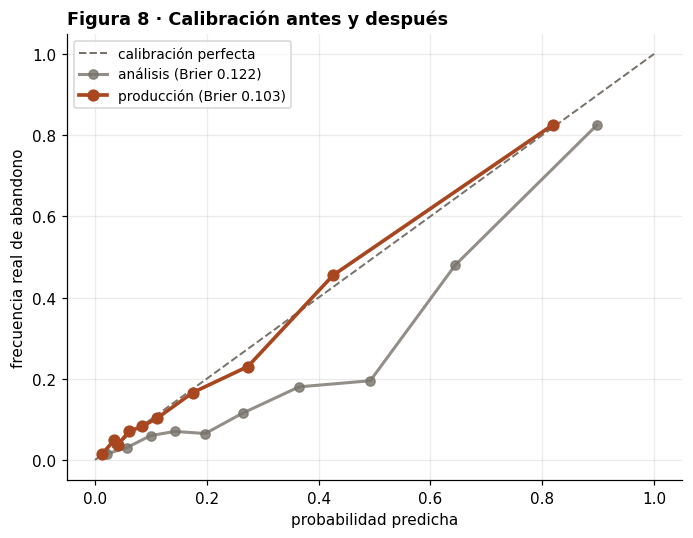

 predicho  real  desvio_pp
    0.012 0.015        0.2
    0.034 0.048        1.4
    0.041 0.038       -0.4
    0.060 0.070        1.0
    0.084 0.083       -0.2
    0.111 0.103       -0.8
    0.175 0.166       -0.9
    0.273 0.230       -4.3
    0.426 0.455        2.9
    0.818 0.825        0.7

desvio maximo: 4.3 pp (antes era 29.7 pp)

Ahora el numero que muestre la app significa lo que dice.


In [0]:
# 3 · La calibración, comprobada
fr_a, mp_a = calibration_curve(y_test, proba,      n_bins=10, strategy="quantile")
fr_p, mp_p = calibration_curve(y_test, proba_prod, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6.4, 5))
ax.plot([0, 1], [0, 1], "--", color=GREY, lw=1.3, label="calibración perfecta")
ax.plot(mp_a, fr_a, "o-", color=GREY,  lw=2, ms=6, alpha=0.8,
        label=f"análisis (Brier {brier:.3f})")
ax.plot(mp_p, fr_p, "o-", color=CHURN, lw=2.4, ms=7,
        label=f"producción (Brier {brier_score_loss(y_test, proba_prod):.3f})")
ax.set_xlabel("probabilidad predicha"); ax.set_ylabel("frecuencia real de abandono")
ax.set_title("Figura 8 · Calibración antes y después", fontsize=11.5,
             fontweight="bold", loc="left")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

cal_cmp = pd.DataFrame({"predicho": mp_p, "real": fr_p})
cal_cmp["desvio_pp"] = ((cal_cmp["real"] - cal_cmp["predicho"]) * 100).round(1)
print(cal_cmp.round(3).to_string(index=False))
print(f"\ndesvio máximo: {cal_cmp['desvio_pp'].abs().max():.1f} pp "
      f"(antes era {29.7:.1f} pp)")
print("\nAhora el número que muestre la app significa lo que dice.")

In [0]:
# 4 · Registrar el modelo de producción y dejar la referencia base
#
# Escribe en gold.modelo_produccion_base, NO en gold.modelo_produccion.
# El motivo esta documentado como H32 en la bitacora: antes las dos tablas eran
# la misma y la escribian dos notebooks. Cada reejecución del 05 borraba el
# enlace de Unity Catalog que había puesto el 06, y el fallo solo se notaba
# cuando la aplicación dejaba de cargar el modelo.
#
# Ahora cada tabla tiene un único escritor:
#   gold.modelo_produccion_base  -> lo escribe el 05 (esta celda)
#   gold.modelo_produccion       -> lo escribe el 06, y es la que lee la app
RUN_PROD = None
try:
    with mlflow.start_run(run_name="modelo_produccion") as run:
        mlflow.log_param("familia", ref["familia"])
        mlflow.log_param("gender_excluido", True)
        mlflow.log_param("calibracion", "isotonic_cv5")
        mlflow.log_metric("test_roc_auc",   roc_auc_score(y_test, proba_prod))
        mlflow.log_metric("test_ap",        average_precision_score(y_test, proba_prod))
        mlflow.log_metric("test_brier",     brier_score_loss(y_test, proba_prod))
        mlflow.log_metric("umbral_capacidad", umbral_prod)
        mlflow.sklearn.log_model(modelo_prod, name="modelo")
        RUN_PROD = run.info.run_id
    print("registrado: modelo_produccion ·", RUN_PROD)
except Exception as e:
    print(f"[aviso] MLflow no disponible ({type(e).__name__}); se guardan los parámetros igual")

(spark.createDataFrame(pd.DataFrame([{
    "run_id":               RUN_PROD or "",
    "run_id_analisis":      ref["run_id"],
    "familia":              ref["familia"],
    "gender_excluido":      True,
    "calibracion":          "isotonic_cv5",
    "umbral":               float(umbral_prod),
    "capacidad_fraccion":   float(FRACCION_CAPACIDAD),
    "test_roc_auc":         float(roc_auc_score(y_test, proba_prod)),
    "test_ap":              float(average_precision_score(y_test, proba_prod)),
    "test_brier":           float(brier_score_loss(y_test, proba_prod)),
    "params":               ref["params"],
    "seed":                 SEED,
}]))
 .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
 .saveAsTable(f"{CATALOG}.gold.modelo_produccion_base"))

print(f"\nreferencia guardada en {CATALOG}.gold.modelo_produccion_base")
print("Escritor único: esta tabla la escribe SOLO el notebook 05.")
print("El notebook 06 la lee, le añade el enlace de Unity Catalog y")
print("escribe gold.modelo_produccion, que es la que consume la aplicación.")

🔗 View Logged Model at: https://<workspace>.cloud.databricks.com/ml/experiments/562261887975385/models/m-<run_id>?o=7474644535829777
2026/08/03 02:15:34 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when logging the model to auto infer the model signature. To manually set the signature, please visit https://www.mlflow.org/docs/3.8.1/ml/model/signatures.html for instructions on setting signature on models.


registrado: modelo_produccion · <run_id>

referencia guardada en bank_churn.gold.modelo_produccion
El notebook 06 y la app deben usar ESTE modelo, no el de analisis.


### Actualizar `gold.model_metrics`

Esa tabla se guardó en la sección I con las métricas del **modelo de análisis**. La app y el
notebook 06 leen de ahí, así que mostrarían el Brier de 0,1216 —el del modelo sin calibrar— en
lugar del de producción.

Se reescribe con las métricas correctas y con la estrategia de reparto elegida.

In [0]:
ESTRATEGIA_REPARTO = "cupo_por_pais"

metricas_prod = pd.DataFrame([{
    "modelo": ref["familia"], "variante": "produccion",
    "run_id": RUN_PROD or "", "gender_excluido": True,
    "calibracion": "isotonic_cv5", "estrategia_reparto": ESTRATEGIA_REPARTO,
    "umbral": float(umbral_prod), "umbral_coste": float(UMBRAL_COSTE),
    "capacidad_fraccion": float(FRACCION_CAPACIDAD),
    "roc_auc": float(roc_auc_score(y_test, proba_prod)),
    "average_precision": float(average_precision_score(y_test, proba_prod)),
    "brier": float(brier_score_loss(y_test, proba_prod)),
    "recall": float(m_prod["recall"]), "precision": float(m_prod["precision"]),
    "f1": float(m_prod["f1"]), "accuracy": float(m_prod["accuracy"]),
    "TP": int(m_prod["TP"]), "FP": int(m_prod["FP"]),
    "FN": int(m_prod["FN"]), "TN": int(m_prod["TN"]),
    "techo_recall": float(techo_recall),
    "pct_del_techo": float(m_prod["recall"] / techo_recall),
    "evaluado_en": pd.Timestamp.utcnow().isoformat(),
}])

(spark.createDataFrame(metricas_prod)
      .write.format("delta").mode("overwrite").option("overwriteSchema", "true")
      .saveAsTable(f"{CATALOG}.gold.model_metrics"))
print("model_metrics actualizada · TP =", int(m_prod["TP"]))

model_metrics actualizada · TP = 141


In [ ]:
# ===== CELDA NEUTRALIZADA A PROPOSITO =====
#
# Aquí se guardaban las métricas del modelo de ANÁLISIS en gold.model_metrics.
# Al insertar después la sección J, esta celda quedó por debajo de la que guarda
# las métricas de PRODUCCIÓN, con lo que la sobrescribía: la tabla terminaba con
# TP = 140 (análisis) en lugar de TP = 141 (producción).
#
# El error no era el contenido, sino que DOS CELDAS ESCRIBIAN LA MISMA TABLA y el
# resultado dependía del orden de ejecución. Un artefacto compartido debe tener
# un único escritor.
#
# Las métricas del modelo de análisis no se pierden: aparecen en la tabla
# comparativa de la sección J, junto a las de producción.

print("Celda neutralizada. gold.model_metrics la escribe únicamente la sección J.")

---

## Resumen

| | |
|---|---|
| Modelo de análisis | Random Forest con `gender`, sin calibrar |
| **Modelo de producción** | **Sin `gender`, calibrado isotónicamente** |
| Evaluación | Única, sobre 2.000 filas nunca vistas |
| Umbral | Por capacidad operativa, según el método pre-registrado |
| Sesgo | Coste separado por variable + disyuntiva de equidad cuantificada |

### Los dos criterios incumplidos

**Recall ≥ 0,60** — inalcanzable por construcción: con el cupo de contactos, el techo teórico está
por debajo del criterio. Error de diseño del notebook 00, que no contrastó ambas restricciones. Se
reporta como incumplido y se añade la métrica corregida: porcentaje del recall máximo alcanzable.

**Brecha de recall por país ≤ 10 pp** — incumplido y no corregible sin coste. Es la consecuencia
de maximizar el total capturado con un umbral global cuando las tasas base difieren. La sección G
cuantifica cuántos abandonos costaría igualar el recall; la decisión corresponde al negocio.

**Siguiente:** `06_publicacion_gold` — scoring de los 10.000 clientes con el **modelo de
producción**, tablas Gold con niveles de riesgo y acción sugerida, y reverse ETL a Lakebase.